# Full Pipeline — Image to Final Real/Fake Prediction

This is the final end-to-end inference notebook:

`input image → Community Forensics + DINOv3-L + DINOv3-B stacking probabilities → selected Notebook 5 fusion model → final Real/Fake prediction`

It loads the exact model, feature order, and classification threshold saved by Notebook 5. The three detector outputs are intermediate features only; this notebook evaluates **one final fused system** and contains no model-comparison workflow.

Current evaluation data: all 24,670 balanced images listed in `data/test/manifest.csv` (12,335 real and 12,335 fake). These are the project’s `test_unseen` samples.

## 1. Imports and runtime setup

In [1]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

import gc
import json
import os
import random
from pathlib import Path

CURRENT = Path.cwd().resolve()
PROJECT_ROOT = next((p for p in [CURRENT, CURRENT.parent] if (p / "pyproject.toml").exists()), CURRENT)
%cd {PROJECT_ROOT}
os.environ.setdefault("HF_HOME", str(PROJECT_ROOT / "cache/hf"))
os.environ.setdefault("MPLCONFIGDIR", str(PROJECT_ROOT / "cache/matplotlib"))

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from IPython.display import display
from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    accuracy_score, average_precision_score, balanced_accuracy_score,
    brier_score_loss, confusion_matrix, f1_score, log_loss,
    matthews_corrcoef, precision_recall_curve, precision_score,
    recall_score, roc_auc_score, roc_curve,
)
from tqdm.auto import tqdm

from Data_Pipeline.image_io import load_image_safe
from Evaluation.visualization import use_house_style
from Modeling.common.device import device_report, get_device
from Modeling.dinov3.scorer import DINOv3Scorer
from Modeling.registry import get
from Modeling.stacking.scorer import StackingScorer

use_house_style()
sns.set_theme(style="whitegrid")
DEVICE = get_device()
display(pd.DataFrame([device_report()]))
print("Project root:", PROJECT_ROOT)

/workspace/Coding


,torch,cuda_available,cuda_device_count,mps_available,mps_built,selected
0,2.13.0+cu130,True,1,False,False,cuda


Project root: /workspace/Coding


## 2. Configuration and selected Notebook 5 fusion artifact

In [2]:
IMAGE_DIR = PROJECT_ROOT  # Manifest paths are relative to the Coding project root
LABEL_CSV = PROJECT_ROOT / "data/test/manifest.csv"  # 24,670 balanced test-unseen images
MAX_IMAGES = None  # Process every row in LABEL_CSV
RANDOM_SEED = 1337
BATCH_SIZE = 8

DINO_L_CHECKPOINT = PROJECT_ROOT / "weights/dinov3/notebook_dinov3/best_robust.pt"
STACKING_CHECKPOINT = PROJECT_ROOT / "weights/stacking/notebook_vitb/best_robust.pt"
FUSION_ARTIFACT = PROJECT_ROOT / "weights/fusion/selected_final_fusion.joblib"
OUTPUT_DIR = PROJECT_ROOT / "outputs/full_pipeline"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR = OUTPUT_DIR / "score_cache_test_24670"
CACHE_DIR.mkdir(parents=True, exist_ok=True)

artifact = joblib.load(FUSION_ARTIFACT)
fusion_model = artifact["model"]
FINAL_MODEL_NAME = artifact["model_name"]
FINAL_THRESHOLD = float(artifact["threshold"])
FEATURE_COLUMNS = list(artifact["feature_order"])
FINAL_BEST_PARAMS = artifact.get("best_params", {})

configuration = pd.DataFrame({
    "setting": ["fusion model", "threshold", "hyperparameters", "images requested", "device"],
    "value": [FINAL_MODEL_NAME, FINAL_THRESHOLD, json.dumps(FINAL_BEST_PARAMS), MAX_IMAGES, str(DEVICE)],
})
display(configuration)
print("Fusion feature order:", FEATURE_COLUMNS)

,setting,value
0,fusion model,SVM (linear)
1,threshold,0.7
2,hyperparameters,"{""model__C"": 0.1}"
3,images requested,None
4,device,cuda


Fusion feature order: ['Community Forensics Pr', 'DINOv3-L detector Pr', 'DINOv3-B stacking detector Pr']


## 3. Load all test-unseen images and ground-truth labels from the manifest

In [3]:
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".webp", ".bmp", ".tif", ".tiff"}
LABEL_ALIASES = {
    "real": 0, "authentic": 0, "human": 0,
    "fake": 1, "ai": 1, "generated": 1, "synthetic": 1, "aigc": 1,
}

def parse_label(value):
    if pd.isna(value):
        return None
    key = str(value).strip().lower()
    return {"0":0, "0.0":0, "1":1, "1.0":1}.get(key, LABEL_ALIASES.get(key))

csv_labels = {}
if LABEL_CSV is not None:
    label_frame = pd.read_csv(LABEL_CSV)
    manifest_paths = [Path(str(path)) for path in label_frame.path]
    paths = [path.resolve() if path.is_absolute() else (IMAGE_DIR / path).resolve()
             for path in manifest_paths]
    csv_labels = {str(path): parse_label(label) for path, label in zip(paths, label_frame.label)}
else:
    paths = sorted(path.resolve() for path in IMAGE_DIR.rglob("*")
                   if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS)

if MAX_IMAGES is not None and len(paths) > MAX_IMAGES:
    paths = sorted(random.Random(RANDOM_SEED).sample(paths, MAX_IMAGES))

def infer_label(path):
    if csv_labels:
        return csv_labels.get(str(path.resolve()))
    folders = [part.lower() for part in path.relative_to(IMAGE_DIR.resolve()).parts[:-1]]
    labels = [LABEL_ALIASES[part] for part in folders if part in LABEL_ALIASES]
    return labels[0] if labels else None

results = pd.DataFrame({
    "path": [str(path) for path in paths],
    "relative_path": [str(path.relative_to(IMAGE_DIR.resolve())) for path in paths],
    "label": pd.array([infer_label(path) for path in paths], dtype="Int64"),
})
print(f"Images: {len(results)} | labelled: {results.label.notna().sum()} | real: {(results.label == 0).sum()} | fake: {(results.label == 1).sum()}")
display(results.head(10))

Images: 24670 | labelled: 24670 | real: 12335 | fake: 12335


,path,relative_path,label
0,/workspace/Coding/data/test/images/wildfake/fa...,data/test/images/wildfake/fake/GALIP/GAN_based...,1
1,/workspace/Coding/data/test/images/wildfake/fa...,data/test/images/wildfake/fake/GALIP/GAN_based...,1
2,/workspace/Coding/data/test/images/wildfake/fa...,data/test/images/wildfake/fake/GALIP/GAN_based...,1
3,/workspace/Coding/data/test/images/wildfake/fa...,data/test/images/wildfake/fake/GALIP/GAN_based...,1
4,/workspace/Coding/data/test/images/wildfake/fa...,data/test/images/wildfake/fake/GALIP/GAN_based...,1
5,/workspace/Coding/data/test/images/wildfake/fa...,data/test/images/wildfake/fake/GALIP/GAN_based...,1
6,/workspace/Coding/data/test/images/wildfake/fa...,data/test/images/wildfake/fake/GALIP/GAN_based...,1
7,/workspace/Coding/data/test/images/wildfake/fa...,data/test/images/wildfake/fake/GALIP/GAN_based...,1
8,/workspace/Coding/data/test/images/wildfake/fa...,data/test/images/wildfake/fake/GALIP/GAN_based...,1
9,/workspace/Coding/data/test/images/wildfake/fa...,data/test/images/wildfake/fake/GALIP/GAN_based...,1


## 4. Reusable detector-scoring helpers

In [4]:
def release_memory():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    elif getattr(torch.backends, "mps", None) and torch.backends.mps.is_available():
        torch.mps.empty_cache()

def score_paths(scorer, image_paths, description, cache_name, batch_size=BATCH_SIZE):
    cache_path = CACHE_DIR / f"{cache_name}.npy"
    done_path = CACHE_DIR / f"{cache_name}.done.npy"
    if cache_path.exists() and done_path.exists():
        probabilities = np.load(cache_path, mmap_mode="r+")
        done = np.load(done_path)
        print(f"{description}: resuming cache with {done.sum()}/{len(done)} rows complete")
    else:
        probabilities = np.lib.format.open_memmap(
            cache_path, mode="w+", dtype=np.float64, shape=(len(image_paths),))
        probabilities[:] = np.nan
        done = np.zeros(len(image_paths), dtype=bool)
        np.save(done_path, done)
    for start in tqdm(range(0, len(image_paths), batch_size), desc=description, unit="batch"):
        stop = min(start + batch_size, len(image_paths))
        pending = [position for position in range(start, stop) if not done[position]]
        images, positions = [], []
        for position in pending:
            path = image_paths[position]
            image, error = load_image_safe(path)
            if image is not None:
                images.append(image)
                positions.append(position)
            else:
                print(f"Unreadable image skipped: {path} ({error})")
                done[position] = True
        if images:
            probabilities[positions] = scorer.score_checked(images)
            done[positions] = True
            for image in images:
                image.close()
        probabilities.flush()
        np.save(done_path, done)
    print(f"{description}: scored {np.isfinite(probabilities).sum()}/{len(probabilities)}")
    return np.asarray(probabilities).copy()

image_paths = [Path(path) for path in results.path]

## 5. Produce the three input probabilities

In [5]:
print("1/3 Community Forensics")
community = get("community_forensics", device=str(DEVICE))
results["Community Forensics Pr"] = score_paths(
    community, image_paths, "Community Forensics", "community_forensics")
del community
release_memory()

print("2/3 DINOv3-L detector")
dinov3_l = DINOv3Scorer(
    checkpoint=str(DINO_L_CHECKPOINT), device=str(DEVICE), n_crops=8, seed=RANDOM_SEED)
results["DINOv3-L detector Pr"] = score_paths(
    dinov3_l, image_paths, "DINOv3-L", "dinov3_l", batch_size=2)
del dinov3_l
release_memory()

print("3/3 DINOv3-B stacking detector")
dinov3_b_stacking = StackingScorer(
    checkpoint=str(STACKING_CHECKPOINT), device=str(DEVICE), n_crops=3, seed=RANDOM_SEED)
results["DINOv3-B stacking detector Pr"] = score_paths(
    dinov3_b_stacking, image_paths, "DINOv3-B stacking", "dinov3_b_stacking", batch_size=4)
del dinov3_b_stacking
release_memory()

display(results[["relative_path", "label", *FEATURE_COLUMNS]].round(5))

1/3 Community Forensics


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Community Forensics:   0%|          | 0/3084 [00:00<?, ?batch/s]

Community Forensics: scored 24670/24670


2/3 DINOv3-L detector


...

3/3 DINOv3-B stacking detector


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

DINOv3-B stacking:   0%|          | 0/6168 [00:00<?, ?batch/s]

DINOv3-B stacking: scored 24670/24670


,relative_path,label,Community Forensics Pr,DINOv3-L detector Pr,DINOv3-B stacking detector Pr
0,data/test/images/wildfake/fake/GALIP/GAN_based...,1,1.00000,0.98171,0.91618
1,data/test/images/wildfake/fake/GALIP/GAN_based...,1,1.00000,0.89524,0.92421
2,data/test/images/wildfake/fake/GALIP/GAN_based...,1,1.00000,0.96864,0.92384
3,data/test/images/wildfake/fake/GALIP/GAN_based...,1,1.00000,0.92238,0.92357
4,data/test/images/wildfake/fake/GALIP/GAN_based...,1,1.00000,0.96752,0.92190
...,...,...,...,...,...
24665,data/test/images/wildfake/real/imagenet/imagen...,0,0.00001,0.06670,0.14381
24666,data/test/images/wildfake/real/imagenet/imagen...,0,0.00000,0.02086,0.12781
24667,data/test/images/wildfake/real/imagenet/imagen...,0,0.00040,0.05777,0.20642
24668,data/test/images/wildfake/real/imagenet/imagen...,0,0.00004,0.03123,0.18537


## 6. Apply the selected fusion model and make one final prediction

In [6]:
scored_mask = results[FEATURE_COLUMNS].notna().all(axis=1)
fusion_input = results.loc[scored_mask, FEATURE_COLUMNS].to_numpy(dtype=np.float64)
results["final_probability"] = np.nan
results.loc[scored_mask, "final_probability"] = fusion_model.predict_proba(fusion_input)[:, 1]
results["final_prediction"] = pd.array(
    np.where(results.final_probability.notna(),
             (results.final_probability >= FINAL_THRESHOLD).astype(int), pd.NA), dtype="Int64")
results["final_label"] = results.final_prediction.map({0:"Real", 1:"Fake"})
results["final_confidence"] = np.where(
    results.final_probability.notna(),
    np.where(results.final_prediction == 1, results.final_probability, 1-results.final_probability),
    np.nan)
results["correct"] = pd.array([
    pd.NA if pd.isna(truth) or pd.isna(prediction) else bool(truth == prediction)
    for truth, prediction in zip(results.label, results.final_prediction)
], dtype="boolean")

display_columns = ["relative_path", "label", *FEATURE_COLUMNS,
                   "final_probability", "final_prediction", "final_label", "final_confidence", "correct"]
display(results[display_columns].round(5))

,relative_path,label,Community Forensics Pr,DINOv3-L detector Pr,DINOv3-B stacking detector Pr,final_probability,final_prediction,final_label,final_confidence,correct
0,data/test/images/wildfake/fake/GALIP/GAN_based...,1,1.00000,0.98171,0.91618,1.00000,1,Fake,1.00000,True
1,data/test/images/wildfake/fake/GALIP/GAN_based...,1,1.00000,0.89524,0.92421,1.00000,1,Fake,1.00000,True
2,data/test/images/wildfake/fake/GALIP/GAN_based...,1,1.00000,0.96864,0.92384,1.00000,1,Fake,1.00000,True
3,data/test/images/wildfake/fake/GALIP/GAN_based...,1,1.00000,0.92238,0.92357,1.00000,1,Fake,1.00000,True
4,data/test/images/wildfake/fake/GALIP/GAN_based...,1,1.00000,0.96752,0.92190,1.00000,1,Fake,1.00000,True
...,...,...,...,...,...,...,...,...,...,...
24665,data/test/images/wildfake/real/imagenet/imagen...,0,0.00001,0.06670,0.14381,0.00008,0,Real,0.99992,True
24666,data/test/images/wildfake/real/imagenet/imagen...,0,0.00000,0.02086,0.12781,0.00004,0,Real,0.99996,True
24667,data/test/images/wildfake/real/imagenet/imagen...,0,0.00040,0.05777,0.20642,0.00011,0,Real,0.99989,True
24668,data/test/images/wildfake/real/imagenet/imagen...,0,0.00004,0.03123,0.18537,0.00007,0,Real,0.99993,True


## 7. Final fused-system accuracy on labelled cases

In [7]:
evaluation_mask = results.label.notna() & results.final_probability.notna()
metrics = pd.DataFrame()
if evaluation_mask.any():
    y_true = results.loc[evaluation_mask, "label"].to_numpy(dtype=int)
    y_probability = results.loc[evaluation_mask, "final_probability"].to_numpy(dtype=float)
    y_prediction = (y_probability >= FINAL_THRESHOLD).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_prediction, labels=[0, 1]).ravel()
    metric_values = {
        "model": FINAL_MODEL_NAME, "threshold": FINAL_THRESHOLD,
        "images": len(y_true), "accuracy": accuracy_score(y_true, y_prediction),
        "precision": precision_score(y_true, y_prediction, zero_division=0),
        "recall_sensitivity": recall_score(y_true, y_prediction, zero_division=0),
        "specificity": tn / (tn + fp), "f1": f1_score(y_true, y_prediction, zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_prediction),
        "mcc": matthews_corrcoef(y_true, y_prediction),
        "roc_auc": roc_auc_score(y_true, y_probability),
        "pr_auc": average_precision_score(y_true, y_probability),
        "log_loss": log_loss(y_true, np.clip(y_probability, 1e-7, 1-1e-7), labels=[0, 1]),
        "brier": brier_score_loss(y_true, y_probability),
        "tn":int(tn), "fp":int(fp), "fn":int(fn), "tp":int(tp),
    }
    metrics = pd.DataFrame([metric_values])
    display(metrics.T.rename(columns={0:"value"}))
    display(pd.DataFrame([[tn, fp], [fn, tp]], index=["Actual Real", "Actual Fake"],
                         columns=["Predicted Real", "Predicted Fake"]))
else:
    print("Prediction-only mode: add labels to calculate accuracy metrics.")

,value
model,SVM (linear)
threshold,0.7
images,24670
accuracy,0.996595
precision,0.99813
recall_sensitivity,0.995055
specificity,0.998135
f1,0.99659
balanced_accuracy,0.996595
mcc,0.993195


,Predicted Real,Predicted Fake
Actual Real,12312,23
Actual Fake,61,12274


## 8. Final-system visual diagnostics

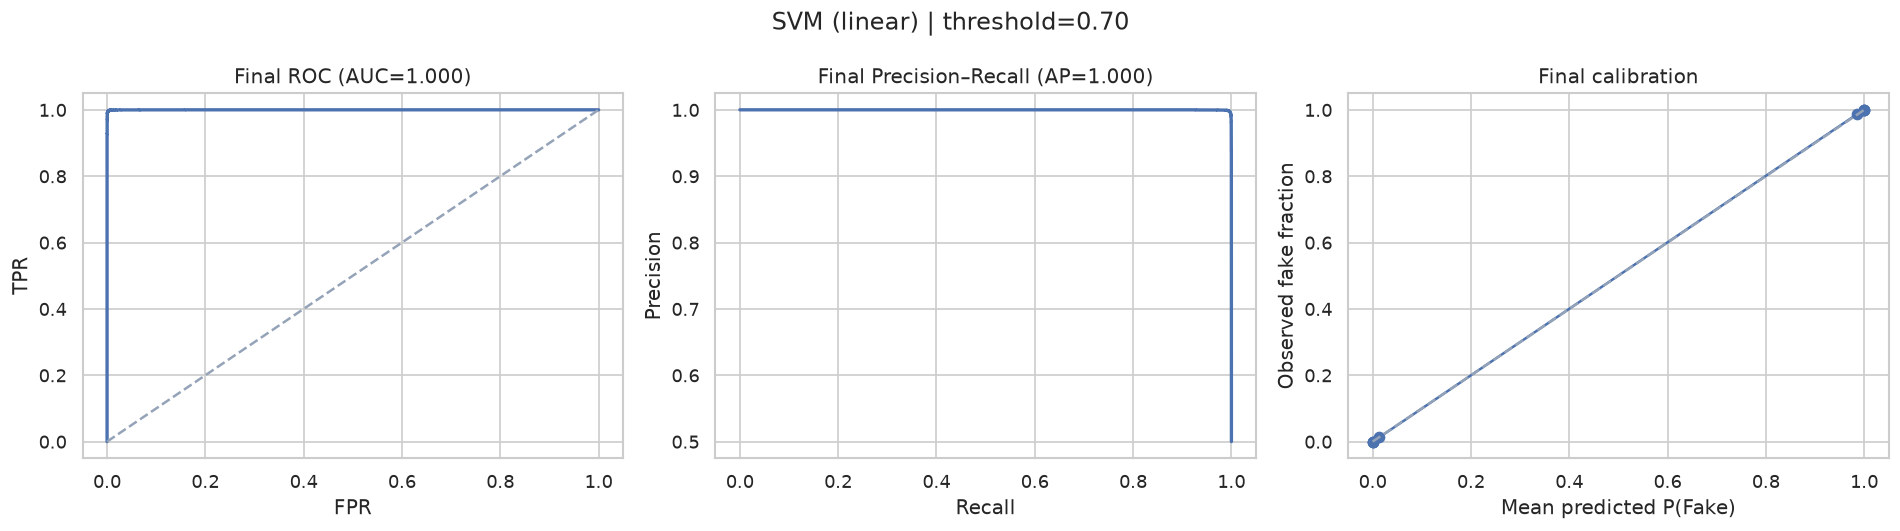

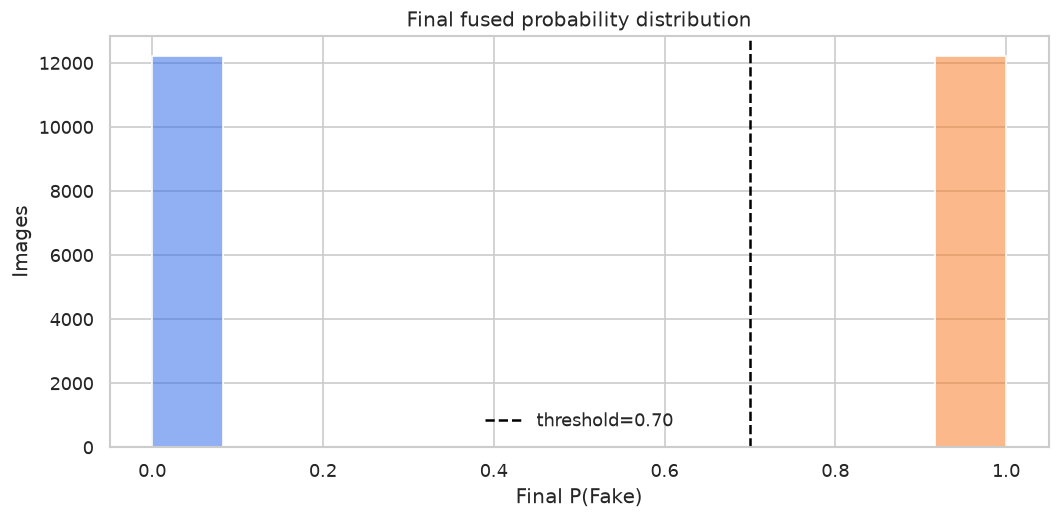

In [8]:
if evaluation_mask.any():
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
    fpr, tpr, _ = roc_curve(y_true, y_probability)
    precision, recall, _ = precision_recall_curve(y_true, y_probability)
    fraction_positive, mean_predicted = calibration_curve(y_true, y_probability, n_bins=8, strategy="quantile")
    axes[0].plot(fpr, tpr, linewidth=2); axes[0].plot([0,1], [0,1], "--", color="#94a3b8")
    axes[0].set(title=f"Final ROC (AUC={roc_auc_score(y_true, y_probability):.3f})", xlabel="FPR", ylabel="TPR")
    axes[1].plot(recall, precision, linewidth=2)
    axes[1].set(title=f"Final Precision–Recall (AP={average_precision_score(y_true, y_probability):.3f})", xlabel="Recall", ylabel="Precision")
    axes[2].plot(mean_predicted, fraction_positive, marker="o"); axes[2].plot([0,1], [0,1], "--", color="#94a3b8")
    axes[2].set(title="Final calibration", xlabel="Mean predicted P(Fake)", ylabel="Observed fake fraction")
    fig.suptitle(f"{FINAL_MODEL_NAME} | threshold={FINAL_THRESHOLD:.2f}")
    fig.tight_layout(); fig.savefig(OUTPUT_DIR / "final_system_curves.png", dpi=160, bbox_inches="tight"); plt.show()

fig, ax = plt.subplots(figsize=(9, 4.5))
sns.histplot(data=results, x="final_probability", hue="label", bins=12, multiple="layer", ax=ax,
             palette={0:"#2563eb", 1:"#f97316"})
ax.axvline(FINAL_THRESHOLD, color="black", linestyle="--", label=f"threshold={FINAL_THRESHOLD:.2f}")
ax.set(title="Final fused probability distribution", xlabel="Final P(Fake)", ylabel="Images")
ax.legend(); fig.tight_layout()
fig.savefig(OUTPUT_DIR / "final_probability_distribution.png", dpi=160, bbox_inches="tight"); plt.show()

## 9. Review mistakes and lowest-confidence predictions

,relative_path,label,final_probability,final_prediction,final_confidence,correct
1315,data/test/images/wildfake/fake/GALIP/GAN_based...,1,0.6280,0,0.3720,False
3410,data/test/images/wildfake/fake/GigaGAN/GAN_bas...,1,0.5805,0,0.4195,False
4534,data/test/images/wildfake/fake/GigaGAN/GAN_bas...,1,0.0190,0,0.9810,False
5108,data/test/images/wildfake/fake/GigaGAN/GAN_bas...,1,0.0096,0,0.9904,False
5481,data/test/images/wildfake/fake/GigaGAN/GAN_bas...,1,0.5000,0,0.5000,False
6377,data/test/images/wildfake/fake/MAGE/Other_base...,1,0.6451,0,0.3549,False
6621,data/test/images/wildfake/fake/MAGE/Other_base...,1,0.4676,0,0.5324,False
7166,data/test/images/wildfake/fake/MAGE/Other_base...,1,0.5764,0,0.4236,False
7340,data/test/images/wildfake/fake/MAGE/Other_base...,1,0.5590,0,0.4410,False
7847,data/test/images/wildfake/fake/MAGE/Other_base...,1,0.6878,0,0.3122,False


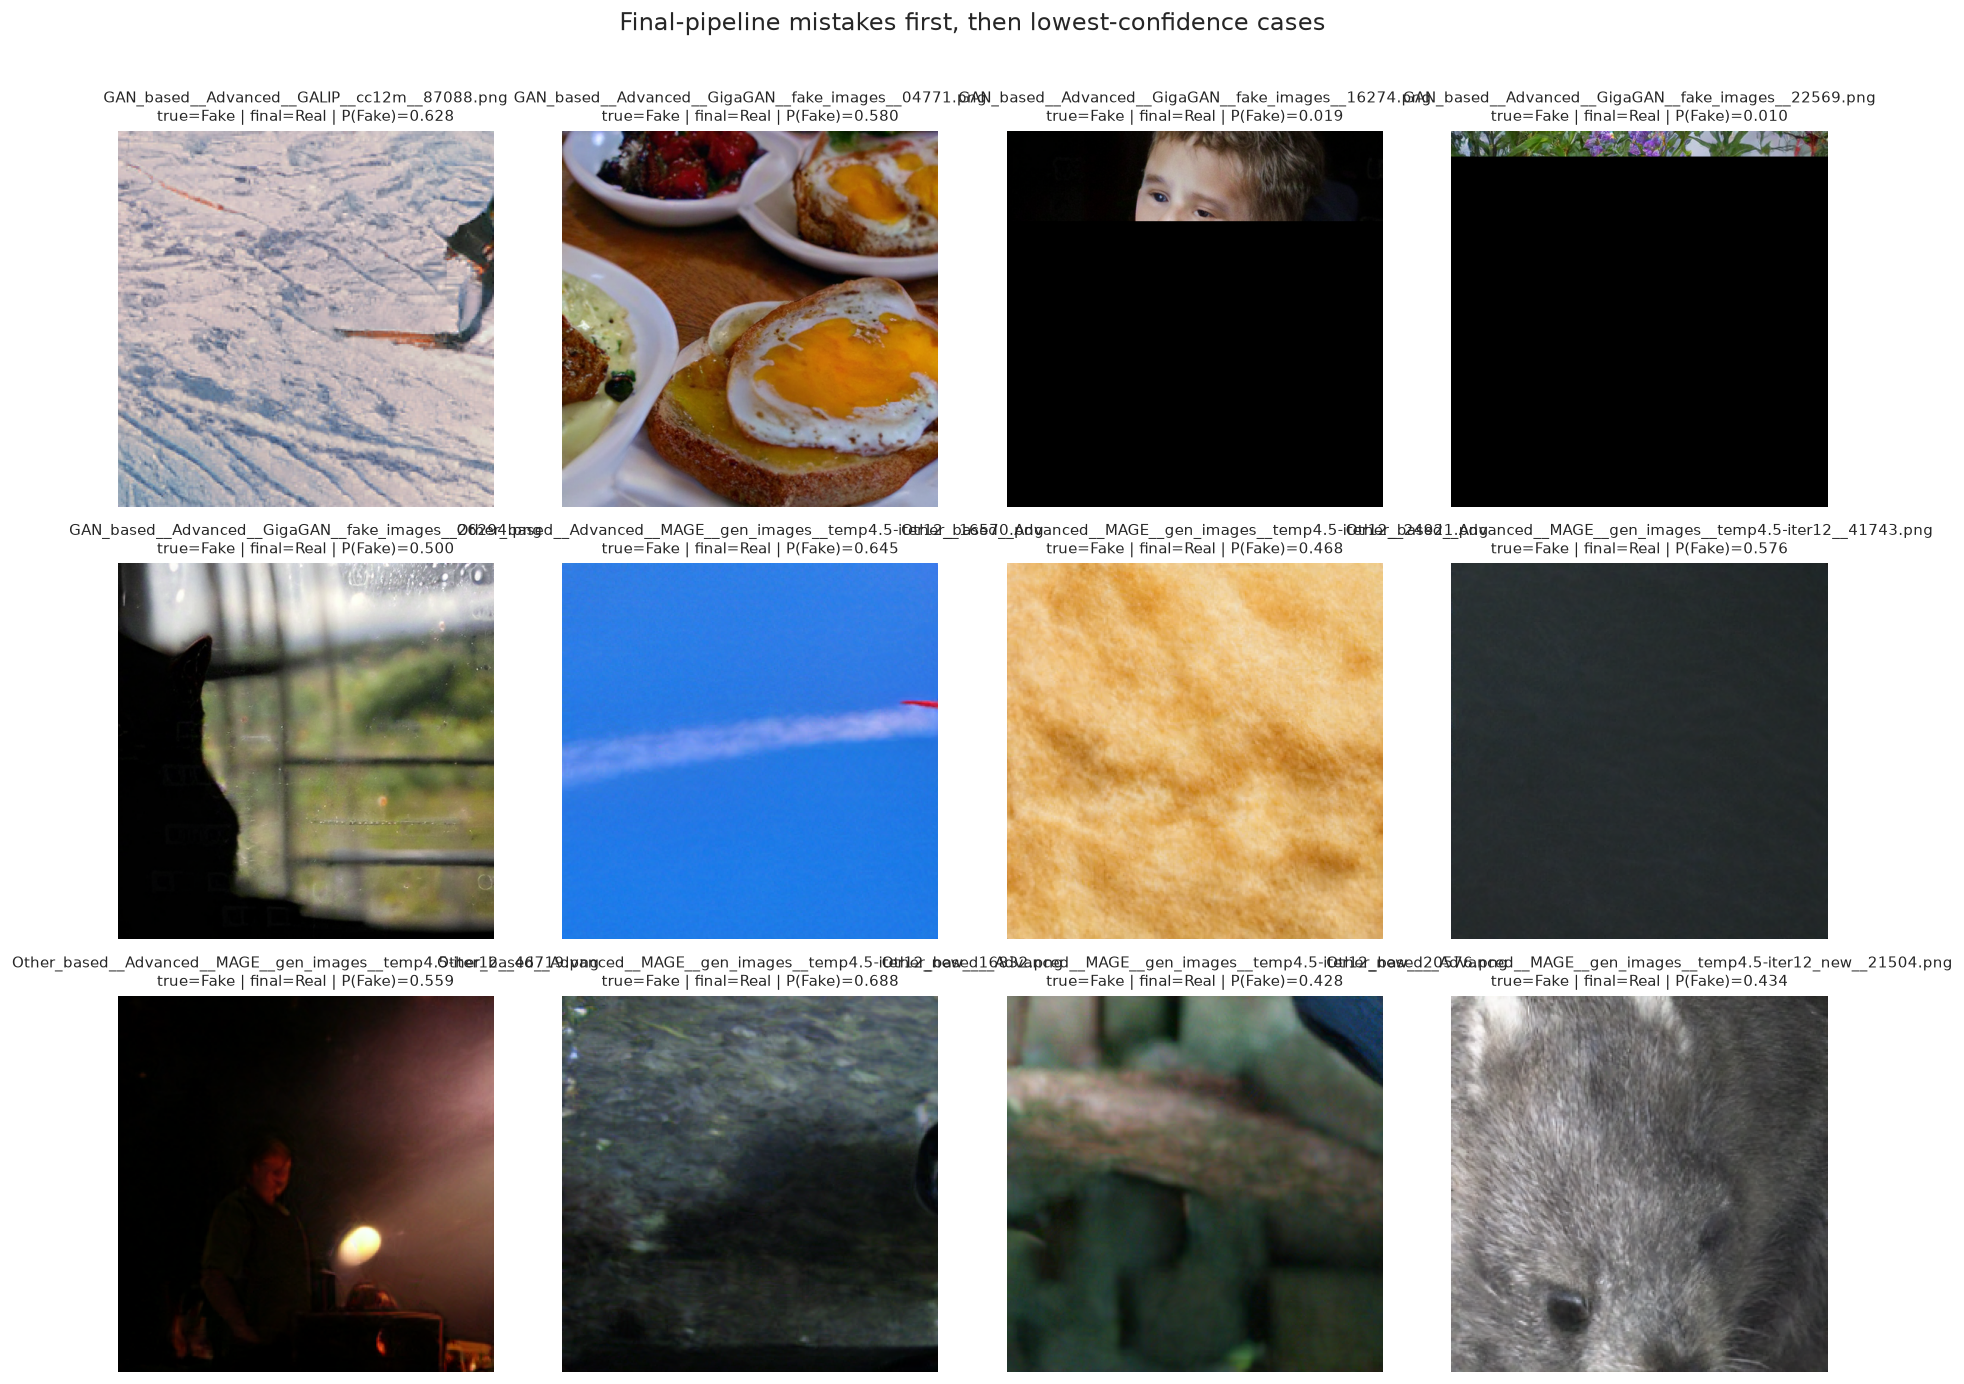

In [9]:
mistakes = results.loc[results.correct == False].copy()
uncertain = results.loc[~results.index.isin(mistakes.index)].copy()
uncertain["distance_from_threshold"] = (uncertain.final_probability - FINAL_THRESHOLD).abs()
review = pd.concat([mistakes, uncertain.sort_values("distance_from_threshold")]).drop_duplicates().head(12)

display(review[["relative_path", "label", "final_probability", "final_prediction", "final_confidence", "correct"]].round(4))
if len(review):
    columns = 4
    rows = int(np.ceil(len(review) / columns))
    fig, axes = plt.subplots(rows, columns, figsize=(15, 3.8 * rows))
    axes = np.asarray(axes).reshape(-1)
    for ax, (_, row) in zip(axes, review.iterrows()):
        image, error = load_image_safe(row.path)
        if image is not None:
            ax.imshow(image); image.close()
        truth = "?" if pd.isna(row.label) else ("Fake" if row.label == 1 else "Real")
        ax.set_title(f"{Path(row.relative_path).name}\ntrue={truth} | final={row.final_label} | P(Fake)={row.final_probability:.3f}", fontsize=9)
        ax.axis("off")
    for ax in axes[len(review):]: ax.axis("off")
    fig.suptitle("Final-pipeline mistakes first, then lowest-confidence cases", y=1.01)
    fig.tight_layout(); fig.savefig(OUTPUT_DIR / "cases_for_review.png", dpi=160, bbox_inches="tight"); plt.show()

## 10. Save reusable prediction outputs

In [10]:
predictions_path = OUTPUT_DIR / "full_pipeline_predictions.csv"
metrics_path = OUTPUT_DIR / "full_pipeline_metrics.csv"
summary_path = OUTPUT_DIR / "full_pipeline_summary.json"
results.to_csv(predictions_path, index=False)
metrics.to_csv(metrics_path, index=False)
summary = {
    "image_directory": str(IMAGE_DIR), "total_images": int(len(results)),
    "labelled_images": int(results.label.notna().sum()), "fusion_artifact": str(FUSION_ARTIFACT),
    "fusion_model": FINAL_MODEL_NAME, "fusion_threshold": FINAL_THRESHOLD,
    "fusion_hyperparameters": FINAL_BEST_PARAMS, "feature_order": FEATURE_COLUMNS,
    "predictions_csv": str(predictions_path), "metrics_csv": str(metrics_path),
}
summary_path.write_text(json.dumps(summary, indent=2, default=str) + "\n")
print("Saved predictions:", predictions_path)
print("Saved metrics:", metrics_path)
print("Saved summary:", summary_path)

Saved predictions: /workspace/Coding/outputs/full_pipeline/full_pipeline_predictions.csv
Saved metrics: /workspace/Coding/outputs/full_pipeline/full_pipeline_metrics.csv
Saved summary: /workspace/Coding/outputs/full_pipeline/full_pipeline_summary.json
